<a href="https://colab.research.google.com/github/LakshmiNarayana5012/Customer-churn/blob/main/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project idea: Predict customers who will leave a company.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape of dataset: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


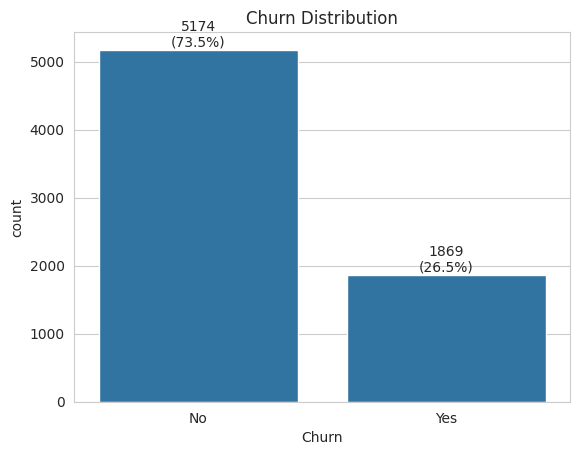

In [ ]:
ax = sns.countplot(x="Churn", data=df)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = f"{100 * count / total:.1f}%"

    ax.annotate(
        f"{count}\n({percentage})",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Churn Distribution")
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:\n", categorical_cols)
print("\nNumerical columns:\n", numerical_cols)

Categorical columns:
 ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Column: OnlineBack

In [ ]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})
df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


#Univariate analysis of numeric columns

This means understanding one numeric column at a time.

#Tenure

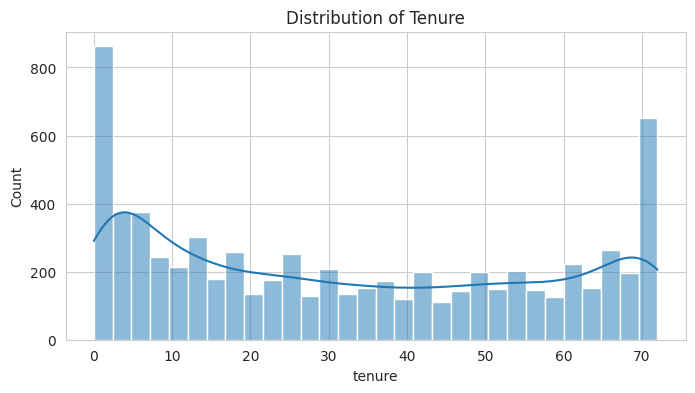

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.show()

#MonthlyCharges

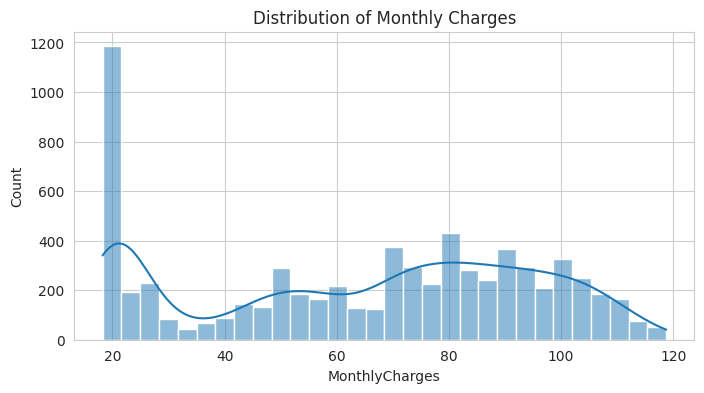

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

#TotalCharges

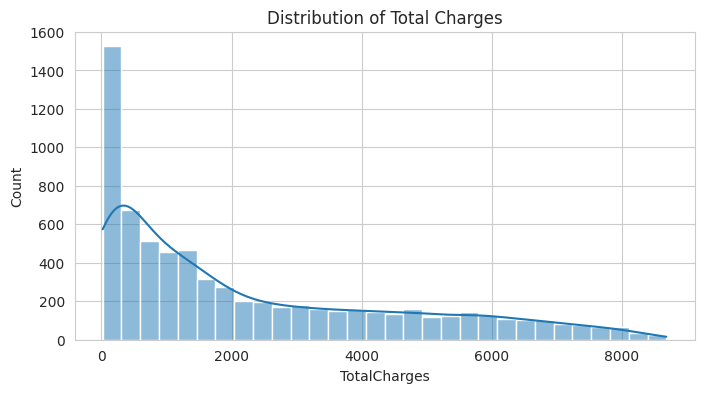

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribution of Total Charges")
plt.show()

#Univariate analysis of categorical columns

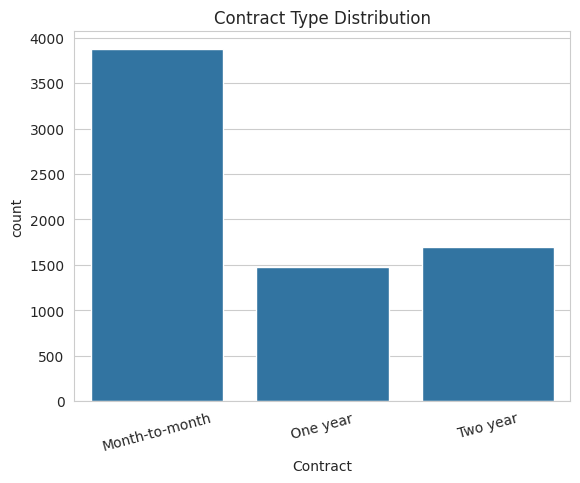

In [ ]:
sns.countplot(x="Contract", data=df)
plt.title("Contract Type Distribution")
plt.xticks(rotation=15)
plt.show()

#Internet service

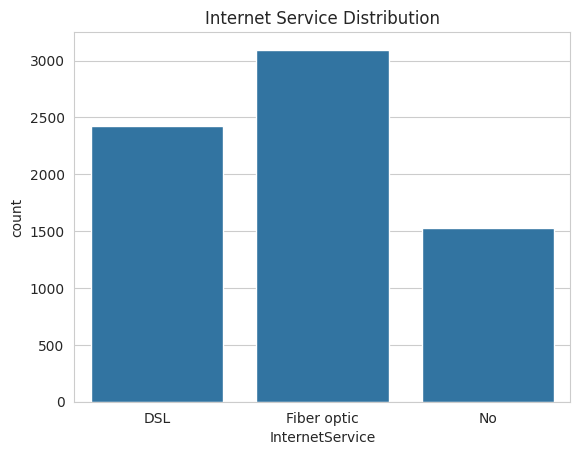

In [ ]:
sns.countplot(x="InternetService", data=df)
plt.title("Internet Service Distribution")
plt.show()

#Payment method

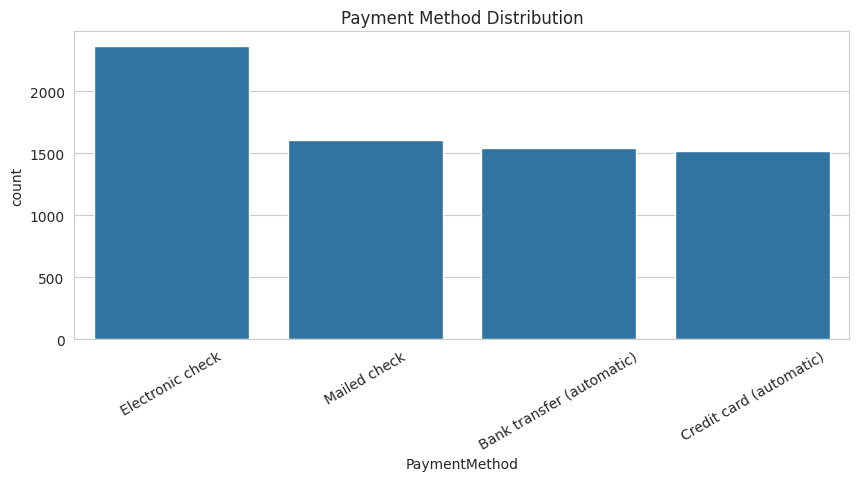

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(x="PaymentMethod", data=df)
plt.title("Payment Method Distribution")
plt.xticks(rotation=30)
plt.show()

#Bivariate analysis: compare columns with churn

#Churn Distribution
Shows overall class balance:

how many customers stayed

how many churned

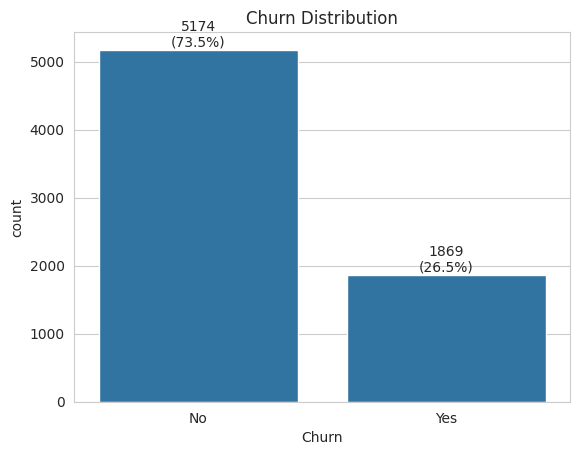

In [ ]:
ax = sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

This tells you whether churn is a large business problem.

#Contract vs Churn
Shows whether churn is higher for:

month-to-month

one year

two year

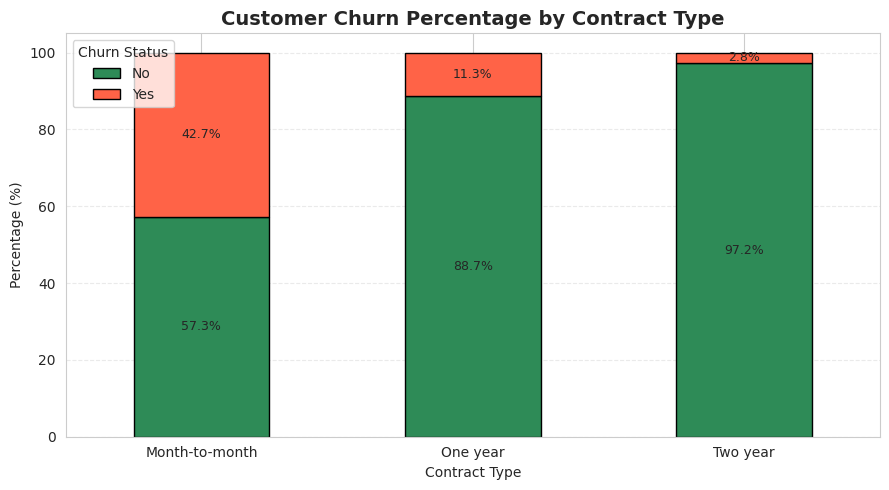

In [ ]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#2E8B57", "#FF6347"],
    edgecolor="black"
)

plt.title("Customer Churn Percentage by Contract Type", fontsize=14, weight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

plt.legend(title="Churn Status")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Customers with month-to-month contracts show the highest churn rate, while customers with one-year and two-year contracts churn significantly less.
This suggests that encouraging customers to move to longer-term contracts may reduce churn

#InternetService vs Churn

DSL

Fiber optic

No internet service

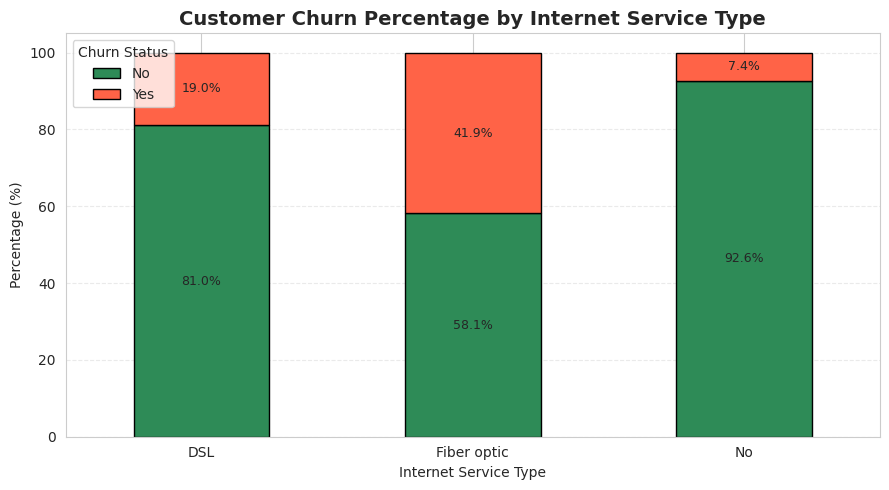

In [ ]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

ax = internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#2E8B57", "#FF6347"],
    edgecolor="black"
)

plt.title("Customer Churn Percentage by Internet Service Type", fontsize=14, weight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Internet Service Type")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

plt.legend(title="Churn Status")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Customers using fiber optic internet service show a significantly higher churn rate compared to DSL users. Customers with no internet service have the lowest churn rate. This may indicate that fiber optic customers experience pricing or service satisfaction issues.

#PaymentMethod vs Churn
Find which payment method has the highest churn.

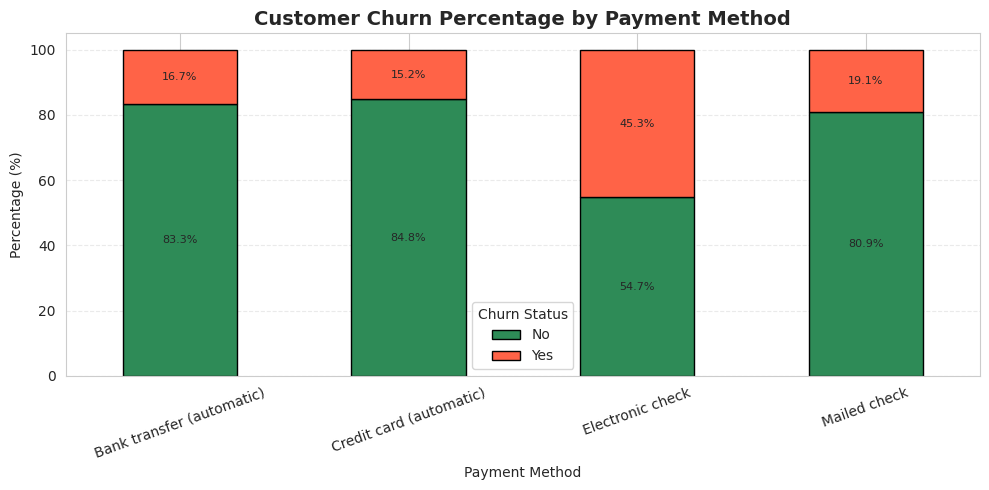

In [ ]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

ax = payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    color=["#2E8B57", "#FF6347"],
    edgecolor="black"
)

plt.title("Customer Churn Percentage by Payment Method", fontsize=14, weight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Payment Method")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8)

plt.legend(title="Churn Status")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Electronic check often has higher churn.

#Tenure Distribution by Churn
Shows whether churned customers are newer customers.

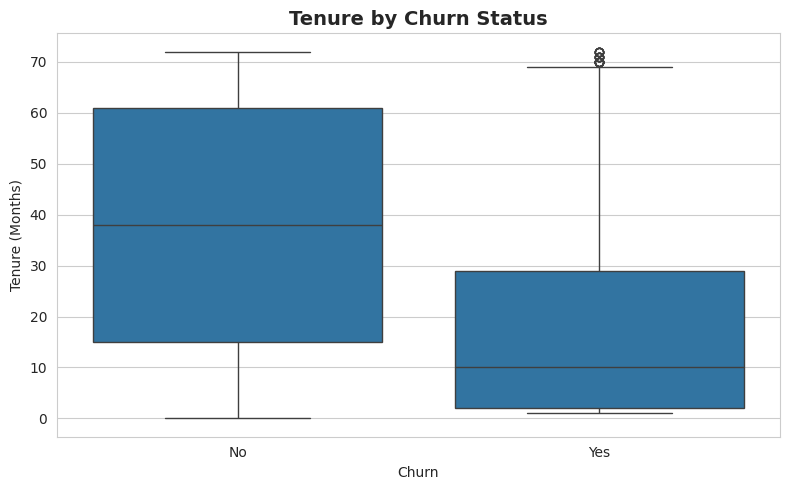

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn Status", fontsize=14, weight="bold")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

Customers who churn usually have lower tenure.

#Monthly Charges by Churn
Checks whether churn is related to monthly pricing.

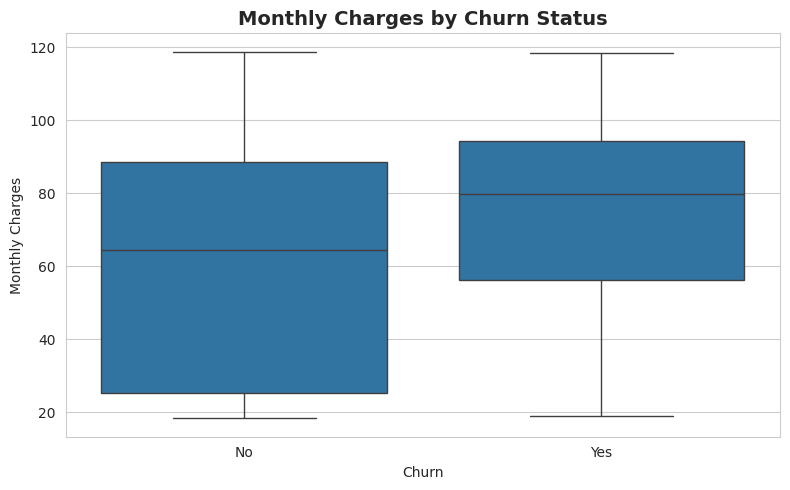

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status", fontsize=14, weight="bold")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

Customers paying more monthly may churn more.

#Total Charges by Churn
Shows how total historical spend differs between churned and retained customers.

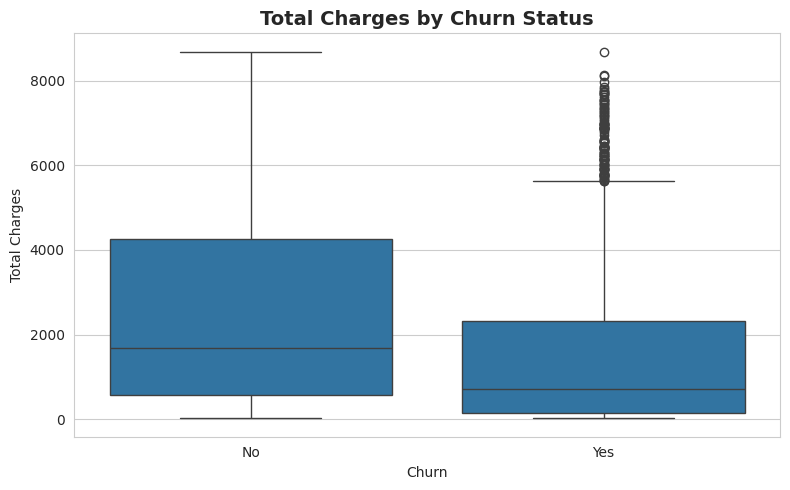

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn Status", fontsize=14, weight="bold")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

Customers who stay longer usually have higher total charges.

#Tenure Group vs Churn
Makes tenure easier to understand by grouping customers.

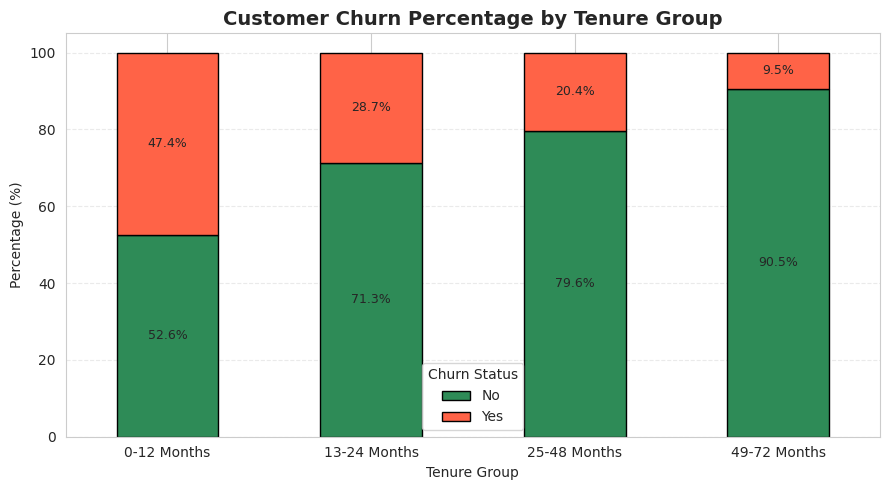

In [ ]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

tenure_churn = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100

ax = tenure_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#2E8B57", "#FF6347"],
    edgecolor="black"
)

plt.title("Customer Churn Percentage by Tenure Group", fontsize=14, weight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

plt.legend(title="Churn Status")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

New customers in the first 12 months are often highest risk.

#Tech Support vs Churn
Shows whether support services reduce churn.

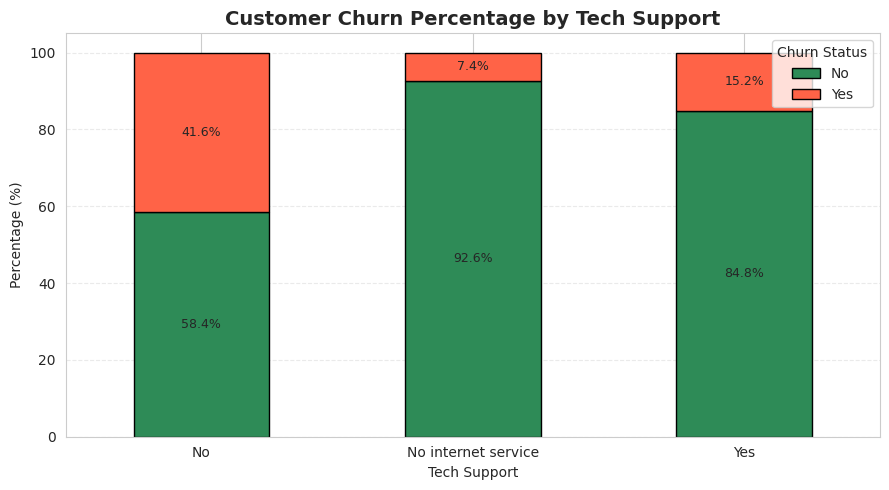

In [ ]:
tech_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

ax = tech_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#2E8B57", "#FF6347"],
    edgecolor="black"
)

plt.title("Customer Churn Percentage by Tech Support", fontsize=14, weight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Tech Support")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9)

plt.legend(title="Churn Status")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Customers without tech support often churn more.

#Correlation Heatmap
Shows relationships between numeric variables.

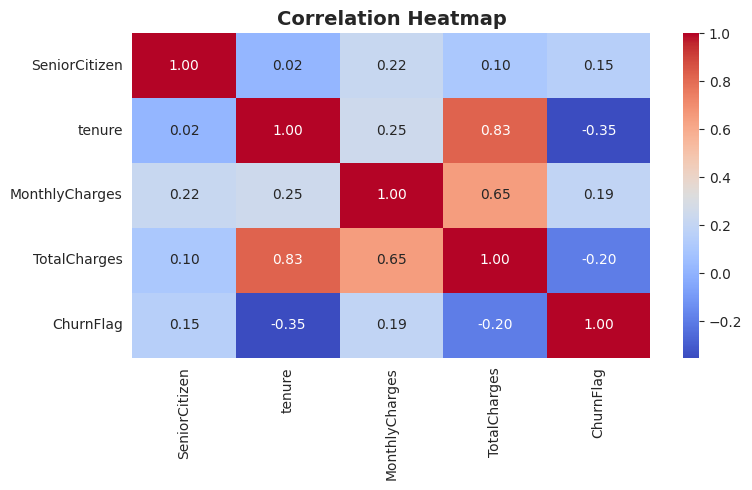

In [ ]:
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})

corr = df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

This helps quantify which numeric features relate most to churn.

In [ ]:
security_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100
security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [ ]:
security_churn.to_csv("onlinesecurity_churn_summary.csv")

# Final Findings:
#
# 1. Month-to-month contract customers have the highest churn rate.
# 2. Customers in the first 12 months are at the highest risk of leaving.
# 3. Fiber optic users show higher churn compared to DSL users.
# 4. Customers without TechSupport or OnlineSecurity churn more.
# 5. Higher monthly charges appear to be associated with greater churn.

# Business Recommendations:
#
# 1. Encourage month-to-month customers to switch to longer-term contracts.
# 2. Focus retention efforts on customers in their first year.
# 3. Review service quality and pricing for fiber optic customers.
# 4. Promote value-added services like TechSupport and OnlineSecurity.
# 5. Monitor high monthly charge customers and target them with retention offers.